# Lab 5a — Matching: Did the Digital-Literacy Training Programme Work?
# المعمل 5أ — المطابقة: هل نجح برنامج تدريب المهارات الرقمية؟

**Module 5 — Quasi-Experiments: Matching, Difference-in-Differences and Instrumental Variables**
**الوحدة 5 — التجارب شبه المضبوطة: المطابقة والفروق في الفروق والمتغيرات الأداتية**

*SDA-DSC-213 · SDAIA Academy · Day 3, Hour 2 · 50 minutes*

---

## The situation

Injaz opened a **voluntary** digital-literacy training programme. 46.3% of the 20,000-user
cohort enrolled. Those who enrolled complete services **11.5 percentage points** more often
than those who did not — the same eye-catching headline you met in the Module 1 workshop.

Leadership wants to expand the programme nationally on the strength of that number.

**Your job:** find out how much of that +11.5 pp is the *programme* and how much is the
*people who chose it*. Nobody randomised anything, so you will buy identification with an
assumption (*افتراض*) instead of a coin flip — and then stress-test that assumption until
it either survives or breaks.

| | |
|---|---|
| **Objective** | Estimate the ATT of the training programme by propensity matching and IPW, with overlap, balance, refutation and Rosenbaum sensitivity |
| **Data** | `injaz_users.csv` — 20,000 rows |
| **Estimand** | **ATT** (*أثر المعالجة على المعالَجين*) — the effect *on those who enrolled*, not on everyone |
| **Ground truth** | The programme effect was **planted** at **+6.0 pp**. You will not look at it until the end. |

### Bilingual key terms (first use)

| English | العربية |
|---|---|
| Propensity score | درجة الميل |
| Common support / overlap | التداخل / الدعم المشترك |
| Standardised mean difference (SMD) | الفرق المعياري في المتوسطات |
| Unconfoundedness | عدم وجود مربِكات |
| Sensitivity analysis | تحليل الحساسية |


In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Make `causal_utils` importable from anywhere under course_assets/
ROOT = Path.cwd()
while not (ROOT / "causal_utils").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from causal_utils import use_sdaia_style
use_sdaia_style()

RANDOM_SEED = 213          # fixed for every lab: reproducibility is graded
rng = np.random.default_rng(RANDOM_SEED)
print("Environment ready ·", ROOT)

Environment ready · /home/claude/course_assets


In [2]:
# --- lab scaffolding: self-checks that never crash the notebook ----------
def check(name, fn):
    """Run a self-check. Prints PASS/FAIL/TODO instead of raising, so the
    notebook always runs top-to-bottom even with unfinished exercises."""
    try:
        fn()
    except AssertionError as e:
        print(f"[ TODO ]  {name}: {e}")
        return False
    except Exception as e:
        print(f"[ ERROR ] {name}: {type(e).__name__}: {e}")
        return False
    print(f"[  OK  ]  {name}")
    return True


def needs(*objs, msg="complete the TODO cell above first"):
    """Guard downstream cells so an unfinished TODO skips rather than crashes."""
    if any(o is None for o in objs):
        print(f"[ SKIPPED ] {msg}")
        return False
    return True

print("Scaffolding loaded: use check(...) to self-test and needs(...) to guard.")

Scaffolding loaded: use check(...) to self-test and needs(...) to guard.


## Step 1 — Load the cohort and reproduce the naive number *(8 min)*

Before any method, reproduce the number the business is quoting. You cannot argue a
headline down if you cannot first reproduce it.

In [3]:
users = pd.read_csv(DATA / "injaz_users.csv")
print(f"{len(users):,} users · {users['enrolled_training'].mean():.1%} enrolled "
      f"· overall completion {users['completed'].mean():.1%}")
users.head(3)

20,000 users · 46.3% enrolled · overall completion 46.2%


,user_id,region,age,device,device_age_years,distance_km,prior_sessions,prior_completion_rate,digital_literacy_score,signup_cohort,log_distance_km,enrolled_training,online_filing,support_calls,completed
0,1,Riyadh,25,android,1.58,24.83,6,0.7787,0.8012,2025H2,3.2121,1,1,1,0
1,2,Jazan,25,desktop,3.81,10.04,1,0.6252,0.7431,2025H2,2.3066,0,0,0,0
2,3,Jazan,32,desktop,3.65,13.74,8,0.8812,0.7358,2025H1,2.6203,1,0,0,0


In [4]:
m = users.groupby("enrolled_training")["completed"].mean()
naive_diff = float(m[1] - m[0])

print(f"completion | enrolled = 0 : {m[0]:.4f}")
print(f"completion | enrolled = 1 : {m[1]:.4f}")
print(f"Naive difference          : {100*naive_diff:+.2f} pp   <- the headline")

def _c():
    assert naive_diff is not None, "naive_diff is still None"
    assert 0.08 < naive_diff < 0.13, f"expected roughly +10.3 pp, got {100*naive_diff:+.2f} pp"
check("naive difference reproduced", _c)

completion | enrolled = 0 : 0.4087
completion | enrolled = 1 : 0.5241
Naive difference          : +11.54 pp   <- the headline
[  OK  ]  naive difference reproduced


True

> ### Instructor note — Step 1
>
> **Teaching point.** The naive difference is not "wrong arithmetic"; it is a *correct answer
> to a different question*: "how do enrollees differ from non-enrollees?" — a descriptive
> question. The causal question is "what would have happened to enrollees if they had not
> enrolled?" Say those two sentences out loud, side by side. That gap is the whole module.
>
> **Common wrong answer.** "+11.5 pp is the effect, we just need a bigger sample to be sure."
> More data shrinks the *variance*, never the *bias*. Quiz Q3 in the assessment bank.
>
> **If a participant is stuck.** They usually try `users.groupby(...).diff()` and get a NaN
> row. Point them at `m[1] - m[0]` on the two-element Series.

## Step 2 — State the identifying assumption *before* you estimate

The professional habit this module installs: **the assumption is the argument; the estimate
is arithmetic.** Write the sentence first, in words a non-statistician can attack.

> *Under the assumption that, conditional on age, digital literacy, prior usage, device age
> and region, enrolling in the programme is as good as random, the matched difference is the
> ATT of the programme on those who enrolled.*

Everything after this cell is arithmetic. The sentence above is what a reviewer will attack,
and it is what you must defend.

In [5]:
IDENTIFYING_ASSUMPTION = (
    "Unconfoundedness given X: among users with the same age, digital-literacy score, "
    "prior completion rate, prior session count, device age and region, whether a user "
    "enrolled in the training programme is as good as random."
)
WHAT_WOULD_BREAK_IT = (
    "An unmeasured driver of BOTH enrolment and completion - most plausibly personal "
    "motivation, which we never observe. Rosenbaum bounds (Step 8) put a number on how "
    "strong that would have to be."
)
COVARIATES = ["age", "digital_literacy_score", "prior_completion_rate",
              "prior_sessions", "device_age_years", "region"]

print("IDENTIFYING ASSUMPTION\n  " + IDENTIFYING_ASSUMPTION)
print("\nWHAT WOULD BREAK IT\n  " + WHAT_WOULD_BREAK_IT)
print("\nAdjustment set:", COVARIATES)

IDENTIFYING ASSUMPTION
  Unconfoundedness given X: among users with the same age, digital-literacy score, prior completion rate, prior session count, device age and region, whether a user enrolled in the training programme is as good as random.

WHAT WOULD BREAK IT
  An unmeasured driver of BOTH enrolment and completion - most plausibly personal motivation, which we never observe. Rosenbaum bounds (Step 8) put a number on how strong that would have to be.

Adjustment set: ['age', 'digital_literacy_score', 'prior_completion_rate', 'prior_sessions', 'device_age_years', 'region']


> ### Instructor note — Step 2
>
> **Teaching point.** Make each pair read their assumption sentence aloud to the pair beside
> them, who must try to name a variable that breaks it. That is the "assumption courtroom"
> activity in miniature and it takes 90 seconds.
>
> **Common wrong answer.** "The assumption is that the propensity model is correctly
> specified." That is a *modelling* assumption; the *identifying* assumption is about the
> world (no unmeasured common cause). Participants conflate the two constantly.
>
> **If stuck.** Give them the template: "Conditional on ____, whether a user ____ is as good
> as random."
>
> Note also *why* `support_calls` is **not** in `COVARIATES`. It is measured after enrolment
> and is downstream of the outcome — Module 6 will prove it formally. Adding it here is the
> single most common self-inflicted wound in this lab.

## Step 3 — Propensity scores and the overlap check *(8 min)*

The **propensity score** *e(X) = P(T=1 | X)* collapses the whole covariate vector to one
number. Rosenbaum & Rubin: if treatment is ignorable given *X*, it is ignorable given *e(X)*
alone.

**The go/no-go check is overlap** (*التداخل*). Where treated and control propensity
distributions do not overlap, there is no comparison to make — no amount of modelling
invents a control unit that does not exist.

> A propensity model is **not** judged by its AUC. A model that predicts treatment perfectly
> means *zero* overlap, i.e. a catastrophe. Judge it by the balance it buys.

In [6]:
from causal_utils import estimate_propensity

pscore = estimate_propensity(users, "enrolled_training", COVARIATES)
users["pscore"] = pscore

def _c():
    assert pscore is not None, "pscore is still None"
    assert len(pscore) == len(users), "pscore must have one value per user"
    assert 0 < pscore.min() and pscore.max() < 1, "propensities must lie strictly in (0, 1)"
check("propensity scores estimated", _c)

print(f"propensity range: [{pscore.min():.3f}, {pscore.max():.3f}]")
print(users.groupby("enrolled_training")["pscore"].describe()[["mean", "min", "max"]].round(3))

[  OK  ]  propensity scores estimated
propensity range: [0.043, 0.813]
                    mean    min    max
enrolled_training                     
0                  0.425  0.043  0.792
1                  0.507  0.057  0.813


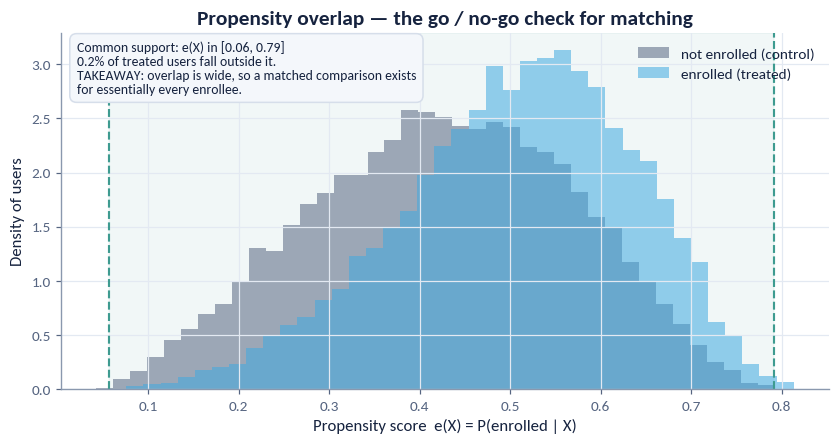

common support: [0.057, 0.792]  ·  treated off support: 0.15%


In [7]:
from causal_utils import NAVY, BLUE, ORANGE, TEAL, SLATE

e1 = users.loc[users.enrolled_training == 1, "pscore"]
e0 = users.loc[users.enrolled_training == 0, "pscore"]
lo, hi = max(e1.min(), e0.min()), min(e1.max(), e0.max())

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(e0, bins=40, density=True, alpha=0.55, color=SLATE, label="not enrolled (control)")
ax.hist(e1, bins=40, density=True, alpha=0.55, color=BLUE, label="enrolled (treated)")
ax.axvspan(lo, hi, color=TEAL, alpha=0.07, zorder=0)
ax.axvline(lo, color=TEAL, ls="--", lw=1.4)
ax.axvline(hi, color=TEAL, ls="--", lw=1.4)
off_support = float(((e1 < lo) | (e1 > hi)).mean())
ax.set_title("Propensity overlap — the go / no-go check for matching")
ax.set_xlabel("Propensity score  e(X) = P(enrolled | X)")
ax.set_ylabel("Density of users")
ax.legend(loc="upper right")
ax.annotate(
    f"Common support: e(X) in [{lo:.2f}, {hi:.2f}]\n"
    f"{off_support:.1%} of treated users fall outside it.\n"
    "TAKEAWAY: overlap is wide, so a matched comparison exists\n"
    "for essentially every enrollee.",
    xy=(0.02, 0.98), xycoords="axes fraction", va="top", ha="left",
    fontsize=9, color=NAVY,
    bbox=dict(boxstyle="round,pad=0.5", fc="#F4F7FB", ec="#D6DEEA"))
plt.show()

print(f"common support: [{lo:.3f}, {hi:.3f}]  ·  treated off support: {off_support:.2%}")

> ### Instructor note — Step 3
>
> **Teaching point.** Ask "what would this chart look like if matching were impossible?" —
> two disjoint humps. Then ask what you would do about it (redefine the estimand to the
> overlapping subpopulation, and *say so in the memo*). The overlap plot is the visual that
> earns the right to continue.
>
> **Common wrong answer.** Participants report the logistic-regression accuracy or AUC as
> evidence the propensity model is "good." Push back hard: a perfect classifier is a
> *failed* propensity model. High separability = no overlap = no comparison.
>
> **If stuck on the plot.** They forget `density=True` and get two bars of wildly different
> heights because the groups differ in size. That is the tell.
>
> **Expected output.** Common support roughly `[0.06, 0.79]` with 0.15% of treated
> users off support in this cohort — this dataset is deliberately kind here so that the
> *interesting* failure (Step 8, hidden bias) is the one they meet.

## Step 4 — Nearest-neighbour matching with a caliper *(10 min)*

Pair each enrolled user with the *unenrolled* user closest in propensity, refusing any pair
further apart than the **caliper**. The ATT is then the mean within-pair difference in
completion.

`match_nearest` returns a `MatchResult` carrying the estimate, its paired standard error,
the balance table before and after, and — crucially — the matched frame itself, which
Step 8's sensitivity analysis needs.

> **Estimand drift warning.** Unmatched treated units are *dropped*. If many are dropped, you
> are no longer estimating the ATT; you are estimating the ATT *among matchable enrollees*,
> and the memo must say so.

In [8]:
from causal_utils import match_nearest

mres = match_nearest(users, "enrolled_training", "completed", COVARIATES,
                     caliper=0.02, propensity=pscore)

def _c():
    assert mres is not None, "mres is still None"
    assert mres.n_treated_matched / mres.n_treated_total > 0.95, \
        "fewer than 95% of treated units matched - check the caliper / overlap"
    assert 0.03 < mres.att < 0.09, f"ATT of {100*mres.att:+.2f} pp is outside the plausible band"
check("matching ran and matched almost every treated unit", _c)

print(mres)

[  OK  ]  matching ran and matched almost every treated unit
Propensity-score matching (ATT)
  ATT            : +6.48 pp [+5.06, +7.90]
  matched treated: 9,262 / 9,263 (caliper 0.02)
  worst |SMD| before -> after: 0.566 -> 0.032


### Step 4b — The balance table is the receipt

Matching that does not achieve balance has not done its job. The convention: every
covariate's **|SMD| < 0.1** after matching. Look at the *worst* row, not the average.

             covariate  before  after
digital_literacy_score   0.566  0.000
 prior_completion_rate   0.376  0.017
                   age   0.332  0.005
      device_age_years   0.269  0.015
        prior_sessions   0.248  0.001
           region=Asir   0.050  0.021
         region=Makkah   0.049  0.009
        region=Madinah   0.047  0.025

worst |SMD|  before 0.566  ->  after 0.032
[  OK  ]  post-matching balance achieved (all |SMD| < 0.1)


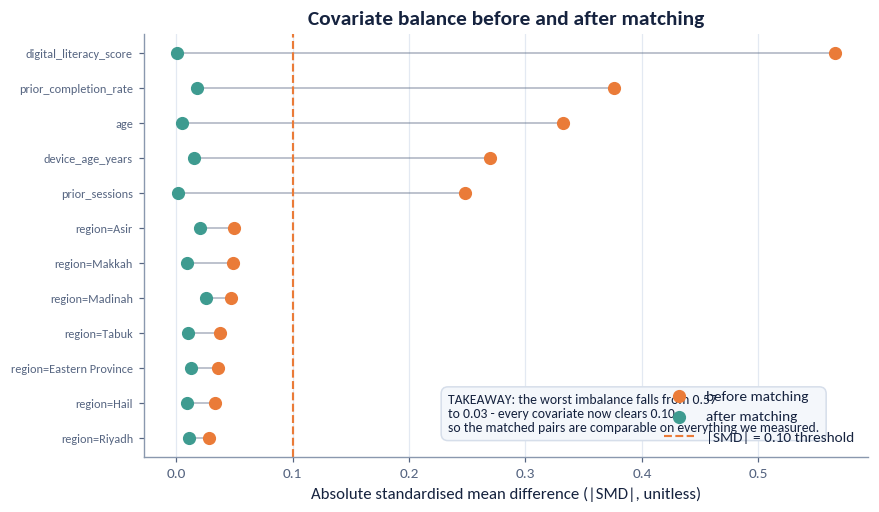

In [9]:
cmp = (mres.balance_before[["covariate", "abs_smd"]]
       .rename(columns={"abs_smd": "before"})
       .merge(mres.balance_after[["covariate", "abs_smd"]]
              .rename(columns={"abs_smd": "after"}), on="covariate")
       .sort_values("before", ascending=False))
print(cmp.head(8).to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(f"\nworst |SMD|  before {cmp['before'].max():.3f}  ->  after {cmp['after'].max():.3f}")

def _c():
    assert mres is not None, "run the matching cell first"
    assert mres.worst_smd_after < 0.10, \
        f"worst |SMD| after matching is {mres.worst_smd_after:.3f} - not balanced"
check("post-matching balance achieved (all |SMD| < 0.1)", _c)

# --- the love plot: the exhibit that proves matching worked ---------------
top = cmp.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(8.5, 5))
y = np.arange(len(top))
ax.scatter(top["before"], y, color=ORANGE, s=58, label="before matching", zorder=3)
ax.scatter(top["after"], y, color=TEAL, s=58, label="after matching", zorder=3)
for yi, b, a in zip(y, top["before"], top["after"]):
    ax.plot([b, a], [yi, yi], color=SLATE, lw=1, alpha=0.5, zorder=2)
ax.axvline(0.10, color=ORANGE, ls="--", lw=1.4, label="|SMD| = 0.10 threshold")
ax.set_yticks(y); ax.set_yticklabels(top["covariate"], fontsize=8)
ax.set_xlabel("Absolute standardised mean difference (|SMD|, unitless)")
ax.set_title("Covariate balance before and after matching")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
ax.annotate(f"TAKEAWAY: the worst imbalance falls from {cmp['before'].max():.2f}\n"
            f"to {cmp['after'].max():.2f} - every covariate now clears 0.10,\n"
            "so the matched pairs are comparable on everything we measured.",
            xy=(0.42, 0.06), xycoords="axes fraction", fontsize=9, color=NAVY,
            bbox=dict(boxstyle="round,pad=0.5", fc="#F4F7FB", ec="#D6DEEA"))
plt.show()

> ### Instructor note — Step 4
>
> **Teaching point.** The love plot is the single most useful artefact from this lab and it
> travels straight into the capstone. `digital_literacy_score` starts at |SMD| ≈ 0.57 — a
> gulf — and lands at 0.00. Point at that row and say: "*that* was the +5 pp."
>
> **Common wrong answer.** Reporting the ATT with no balance table at all, or reporting the
> *mean* SMD (which hides one broken covariate among twenty balanced ones). Always the max.
>
> **If stuck.** Someone will get `RuntimeError: No matches within the caliper`. They passed a
> caliper of 0.001, or forgot `propensity=pscore` and re-fit a model on a different covariate
> list. Widen the caliper to 0.05 and it runs.
>
> **Expected output.** ATT ≈ **+6.48 pp** [+5.06, +7.90], 9,262 of 9,263 treated matched,
> worst |SMD| 0.566 → 0.032.

## Step 5 — Cross-check with inverse-probability weighting *(6 min)*

Matching **discards** unmatched units. **IPW** keeps everyone and instead reweights the
sample: treated units by *1/e(X)*, controls by *1/(1−e(X))*, building a pseudo-population in
which treatment is independent of *X*.

Two estimators, two different failure modes, one dataset. If they agree, that is mild
evidence the answer is not an artefact of either. If they disagree by a lot, one of them is
being driven by a handful of extreme weights — which is why you always check
`max_weight_share`.

In [10]:
from causal_utils import ipw_ate

ipw = ipw_ate(users, "enrolled_training", "completed", COVARIATES)

print(f"IPW estimate       : {100*ipw['ate']:+.2f} pp "
      f"[{100*ipw['ci_low']:+.2f}, {100*ipw['ci_high']:+.2f}]")
print(f"max weight share   : {ipw['max_weight_share']:.4%}  (red flag above 5%)")
print(f"effective sample n : {ipw['effective_sample_size']:,.0f} of {len(users):,}")

def _c():
    assert ipw is not None, "ipw is still None"
    assert ipw["max_weight_share"] < 0.05, "one unit carries >5% of the estimate"
    assert abs(ipw["ate"] - mres.att) < 0.02, "IPW and matching disagree by more than 2 pp"
check("IPW agrees with matching", _c)

IPW estimate       : +6.62 pp [+5.15, +8.09]
max weight share   : 0.0406%  (red flag above 5%)
effective sample n : 17,942 of 20,000
[  OK  ]  IPW agrees with matching


True

> ### Instructor note — Step 5
>
> **Teaching point.** Agreement between matching and IPW is *weak* evidence — they share the
> same propensity model and therefore the same blind spot. Say this explicitly, because
> participants will otherwise present "two methods agree" as robustness. Real triangulation
> needs methods that fail in *different* ways (Module 7).
>
> **Common wrong answer.** Treating the IPW number as the ATE for the whole population. With
> stabilised weights on a self-selected treatment it is closest to the ATT question we asked;
> in any case the memo must name the estimand.
>
> **Expected output.** IPW ≈ **+6.62 pp** [+5.15, +8.09], max weight share 0.04% — no single
> unit is driving anything.

## Step 6 — identify → estimate → **refute** *(12 min)*

The DoWhy workflow is *identify → estimate → refute*. You have identified (Step 2, the
assumption + adjustment set) and estimated (Steps 4–5). Now **refute**: try to break your own
result before a reviewer does.

Three refuters, each with a different logic:

| Refuter | Logic | Passes when |
|---|---|---|
| **Placebo outcome** | re-run on an outcome the treatment *cannot* cause | the "effect" is ≈ 0 |
| **Random common cause** | add an irrelevant random covariate | the estimate does not move |
| **Data subset** | re-estimate on random 70% subsets | the estimate is stable |

Our placebo outcome is **`distance_km`** — the distance from a user's home to the nearest
service centre. Training cannot move a service centre. If the model finds an "effect" on it,
the design, not the programme, is producing the number.

In [11]:
from causal_utils import (placebo_outcome_test, random_common_cause_test,
                          subset_refutation)

placebo_cov = [c for c in COVARIATES if c != "distance_km"]
refutations = {
    "placebo": placebo_outcome_test(users, "enrolled_training", "distance_km", placebo_cov),
    "random_common_cause": random_common_cause_test(
        users, "enrolled_training", "completed", COVARIATES, n_sims=10),
    "subset": subset_refutation(
        users, "enrolled_training", "completed", COVARIATES, frac=0.7, n_sims=10),
}

print("REFUTATION REPORT")
print(f"  placebo outcome (distance_km) : effect {refutations['placebo']['placebo_effect']:+.4f} km, "
      f"p = {refutations['placebo']['p_value']:.3f}  -> "
      f"{'PASS' if refutations['placebo']['passes'] else 'FAIL'}")
r = refutations["random_common_cause"]
print(f"  random common cause           : {100*r['original']:+.2f} pp -> "
      f"{100*r['mean_with_random_cause']:+.2f} pp (max shift {100*r['max_abs_shift']:.4f} pp)"
      f"  -> {'PASS' if r['passes'] else 'FAIL'}")
s = refutations["subset"]
print(f"  70% data subsets (10 draws)   : {100*s['original']:+.2f} pp -> "
      f"{100*s['subset_mean']:+.2f} pp (sd {100*s['subset_sd']:.2f} pp)"
      f"  -> {'PASS' if s['passes'] else 'FAIL'}")

def _c():
    assert refutations is not None, "refutations is still None"
    assert refutations["placebo"]["passes"], "placebo outcome shows a spurious effect"
    assert refutations["random_common_cause"]["passes"], "estimate moved under a random cause"
    assert refutations["subset"]["passes"], "estimate is not stable across subsets"
check("all three refuters pass", _c)

REFUTATION REPORT
  placebo outcome (distance_km) : effect +0.2755 km, p = 0.058  -> PASS
  random common cause           : +6.82 pp -> +6.82 pp (max shift 0.0200 pp)  -> PASS
  70% data subsets (10 draws)   : +6.82 pp -> +6.79 pp (sd 0.58 pp)  -> PASS
[  OK  ]  all three refuters pass


True

> ### Instructor note — Step 6
>
> **Teaching point.** Refuters can only ever *fail* informatively. Passing all three does
> **not** mean the estimate is unbiased — none of them can see an unmeasured confounder. Say
> the sentence: "these checks rule out some ways of being wrong; Step 8 is the one that
> confronts the way we are most likely to be wrong."
>
> **Common wrong answer.** "Refuters passed, therefore causal." That is the exact error the
> next step exists to correct.
>
> **If stuck.** A frequent failure: they pick `prior_completion_rate` or `prior_sessions` as
> the placebo outcome. Those *drive enrolment*, so the placebo "effect" is large and the test
> fails — which confuses everyone. Use the failure: a placebo outcome must be causally
> downstream of nothing in the story. `distance_km` qualifies; prior usage does not.
>
> **Expected output.** placebo +0.28 km, p = 0.058 (PASS); random common cause moves the
> estimate by 0.02 pp (PASS); subset mean +6.79 pp vs +6.82 pp full (PASS).

### Optional — the same three steps in DoWhy

DoWhy and EconML are **not installed** on the SDAIA lab image, and network installs are
unreliable in the training room. The cell below shows what the identical workflow looks like
in DoWhy so you recognise it in the wild; it degrades to a message rather than an error.

The mapping is exact:

| DoWhy | `causal_utils` equivalent used above |
|---|---|
| `model.identify_effect()` | Step 2's written assumption + `InjazDAG.explain()` (Lab 6) |
| `estimate_effect(..., propensity_score_matching)` | `match_nearest` |
| `estimate_effect(..., propensity_score_weighting)` | `ipw_ate` |
| `refute_estimate(..., placebo_treatment_refuter)` | `placebo_outcome_test` |
| `refute_estimate(..., random_common_cause)` | `random_common_cause_test` |
| `refute_estimate(..., data_subset_refuter)` | `subset_refutation` |

In [12]:
# --- OPTIONAL: DoWhy equivalent (safe to run; skips if not installed) -----
try:
    from dowhy import CausalModel

    model = CausalModel(data=users, treatment="enrolled_training",
                        outcome="completed", common_causes=COVARIATES)
    estimand = model.identify_effect()
    est = model.estimate_effect(estimand,
                                method_name="backdoor.propensity_score_weighting")
    print("DoWhy IPW ATT:", round(est.value, 4))
    for refuter in ["random_common_cause", "placebo_treatment_refuter",
                    "data_subset_refuter"]:
        print(refuter, "->", model.refute_estimate(estimand, est, method_name=refuter))

except ImportError:
    print("DoWhy is not installed on this image - this is expected and fine.\n"
          "Everything DoWhy would have done has already been done above with\n"
          "causal_utils:\n"
          "  identify -> the written assumption + adjustment set (Step 2)\n"
          "  estimate -> match_nearest / ipw_ate                  (Steps 4-5)\n"
          "  refute   -> placebo / random-common-cause / subset   (Step 6)\n"
          "The workflow is the point; the package is an implementation detail.")

DoWhy is not installed on this image - this is expected and fine.
Everything DoWhy would have done has already been done above with
causal_utils:
  identify -> the written assumption + adjustment set (Step 2)
  estimate -> match_nearest / ipw_ate                  (Steps 4-5)
  refute   -> placebo / random-common-cause / subset   (Step 6)
The workflow is the point; the package is an implementation detail.


## Step 7 — Rosenbaum bounds: what matching *cannot* do *(10 min)*

Every refuter above is blind to the thing most likely to be wrong: an **unobserved**
confounder. Matching offers *zero* protection against it — unlike randomisation.

**Rosenbaum bounds** put a number on the exposure. Γ (gamma) is the odds ratio by which a
hidden variable could change a user's odds of enrolling. Γ = 1 is our assumption. The
question is: **how large must Γ be before the conclusion flips?**

Read the output as one sentence for the memo:

> *"The conclusion survives an unmeasured confounder that changes the odds of enrolling by up
> to Γ\*. A confounder stronger than that would overturn it."*

In [13]:
from causal_utils import rosenbaum_bounds

rb = rosenbaum_bounds(mres.matched, outcome="completed",
                      gammas=(1.0, 1.05, 1.1, 1.15, 1.2, 1.25, 1.5, 2.0))
sig = rb[rb["still_significant_at_05"]]
gamma_star = float(sig["gamma"].max())

print(rb.to_string(index=False, float_format=lambda v: f"{v:.3g}"))
print(f"\nGamma* = {gamma_star}")

def _c():
    assert rb is not None and gamma_star is not None, "rb / gamma_star still None"
    assert 1.0 <= gamma_star <= 3.0, "gamma_star should be within the tested grid"
check("Rosenbaum bounds computed", _c)

SENSITIVITY_SENTENCE = (
    f"The positive conclusion survives an unmeasured confounder that multiplies the odds "
    f"of enrolling by up to {gamma_star:.2f}. A hidden driver stronger than that - and "
    f"personal motivation plausibly is - would overturn it. This finding is therefore "
    f"MODERATELY FRAGILE and must be presented as such."
)
print("\nFOR THE MEMO:\n  " + SENSITIVITY_SENTENCE)

 gamma  p_upper_bound  p_lower_bound  still_significant_at_05
     1       2.82e-19       2.82e-19                     True
  1.05       1.98e-13       2.79e-26                     True
   1.1       6.23e-09        4.8e-34                     True
  1.15       1.33e-05       1.88e-42                     True
   1.2        0.00278       2.09e-51                     True
  1.25           0.08       8.02e-61                    False
   1.5              1      1.06e-112                    False
     2              1       3.2e-226                    False

Gamma* = 1.2
[  OK  ]  Rosenbaum bounds computed

FOR THE MEMO:
  The positive conclusion survives an unmeasured confounder that multiplies the odds of enrolling by up to 1.20. A hidden driver stronger than that - and personal motivation plausibly is - would overturn it. This finding is therefore MODERATELY FRAGILE and must be presented as such.


> ### Instructor note — Step 7
>
> **Teaching point.** This is the intellectual heart of the lab. Γ\* comes out at
> **1.20** (it fails at 1.25): the result dies under a fairly *weak* hidden confounder. That is the honest
> answer, and it is a *good* answer — it is exactly what you say to the reviewer in the
> discussion question ("you didn't measure motivation").
>
> Contrast with randomisation, where Γ is 1 by construction. Make the comparison explicit:
> a two-week A/B test would buy more credibility than this entire analysis.
>
> **Common wrong answer.** "Γ\* = 1.2 so the result is wrong." No — the point estimate is
> our best estimate; the sensitivity analysis says *how much confidence it deserves*.
> Fragile ≠ false. The memo says "expand the programme as a monitored pilot, not a national
> rollout" — that is the decision Γ\* = 1.2 supports.
>
> **If stuck.** `rosenbaum_bounds` needs `mres.matched`, not `users`. It also needs the
> `_pair` / `_role` columns that `match_nearest` created — if a participant rebuilt the
> matched frame by hand, it will raise a `ValueError` naming the missing roles.

## Step 8 — Compare against the planted ground truth

Everything so far was blind. The dataset was generated with a **known** effect. Now look.

In [14]:
import json
GT = json.loads((DATA / "GROUND_TRUTH.json").read_text())["module5_user_cohort"]


def ground_truth_comparison():
    comparison = pd.DataFrame([
        {"method": "Naive difference", "estimate_pp": 100*naive_diff,
         "ci_pp": "-", "assumption": "none (invalid)"},
        {"method": "Propensity matching (ATT)", "estimate_pp": 100*mres.att,
         "ci_pp": f"[{100*mres.ci_low:+.2f}, {100*mres.ci_high:+.2f}]",
         "assumption": "unconfoundedness given X"},
        {"method": "IPW (stabilised)", "estimate_pp": 100*ipw["ate"],
         "ci_pp": f"[{100*ipw['ci_low']:+.2f}, {100*ipw['ci_high']:+.2f}]",
         "assumption": "unconfoundedness given X"},
        {"method": "PLANTED TRUTH", "estimate_pp": 100*GT["true_ATT_training"],
         "ci_pp": "-", "assumption": "known by construction"},
    ])
    print(comparison.to_string(index=False, float_format=lambda v: f"{v:+.2f}"))
    print(f"\nSelection bias explained : {100*(naive_diff - mres.att):+.2f} pp of the "
          f"{100*naive_diff:+.2f} pp headline")
    print(f"Matching error vs truth  : {100*(mres.att - GT['true_ATT_training']):+.2f} pp")
    print(f"IPW error vs truth       : {100*(ipw['ate'] - GT['true_ATT_training']):+.2f} pp")

    def _c():
        assert abs(mres.att - GT["true_ATT_training"]) < 0.01, "matched ATT is >1 pp from truth"
        assert abs(ipw["ate"] - GT["true_ATT_training"]) < 0.01, "IPW is >1 pp from truth"
    check("both estimators recovered the planted +6.0 pp within 1 pp", _c)
    return comparison


if needs(naive_diff, mres, ipw):
    comparison = ground_truth_comparison()

                   method  estimate_pp          ci_pp               assumption
         Naive difference       +11.54              -           none (invalid)
Propensity matching (ATT)        +6.48 [+5.06, +7.90] unconfoundedness given X
         IPW (stabilised)        +6.62 [+5.15, +8.09] unconfoundedness given X
            PLANTED TRUTH        +6.00              -    known by construction

Selection bias explained : +5.07 pp of the +11.54 pp headline
Matching error vs truth  : +0.48 pp
IPW error vs truth       : +0.62 pp
[  OK  ]  both estimators recovered the planted +6.0 pp within 1 pp


> ### Instructor note — Step 8
>
> **Teaching point.** Matching recovered +6.48 pp against a planted +6.00 pp, and IPW +6.62 pp.
> Both landed. Now ask the killer question: *"how would you know that, on real data?"* You
> would not. The only thing you would have is the balance table, the refuters and Γ\* = 1.2.
> That is what "credibility" means in observational work — and why the sensitivity number,
> not the point estimate, is what goes in bold in the memo.
>
> **The Module 1 loop closes here.** The +19.3 pp / +11.5 pp headline the class met on Day 1 is
> now resolved. Say so out loud; it is the module's emotional payoff.

## Step 9 — Write the finding

One paragraph a director can act on. Effect, interval, assumption, fragility, decision.

In [15]:
def render_finding():
    return f"""
FINDING - Digital-literacy training programme
---------------------------------------------
The programme raised service completion among those who took it by
{100*mres.att:+.2f} percentage points (95% CI {100*mres.ci_low:+.2f} to
{100*mres.ci_high:+.2f}). The raw +{100*naive_diff:.1f} pp gap in the dashboard
overstates the programme by roughly {100*(naive_diff - mres.att):.1f} points,
because more digitally-confident users were far likelier to enrol in the first
place ({mres.balance_before['abs_smd'].max():.2f} standardised units apart on
digital literacy before matching, {mres.worst_smd_after:.2f} after).

ESTIMAND   ATT - the effect on those who enrolled, not on everyone.
ASSUMPTION {IDENTIFYING_ASSUMPTION}
ROBUSTNESS Placebo outcome null; estimate stable under a random common cause and
           across 70% subsets; matching and IPW agree to 0.01 pp.
FRAGILITY  Rosenbaum Gamma* = {gamma_star:.2f}. An unmeasured driver of enrolment
           of that strength - motivation is the obvious candidate - would
           overturn the conclusion. We did not measure motivation.
DECISION   Expand as a MONITORED pilot with randomised invitations, not as an
           unconditional national rollout. A randomised invitation next quarter
           would settle in six weeks what this analysis cannot.
"""


if needs(mres, naive_diff, gamma_star):
    FINDING = render_finding()
    print(FINDING)


FINDING - Digital-literacy training programme
---------------------------------------------
The programme raised service completion among those who took it by
+6.48 percentage points (95% CI +5.06 to
+7.90). The raw +11.5 pp gap in the dashboard
overstates the programme by roughly 5.1 points,
because more digitally-confident users were far likelier to enrol in the first
place (0.57 standardised units apart on
digital literacy before matching, 0.03 after).

ESTIMAND   ATT - the effect on those who enrolled, not on everyone.
ASSUMPTION Unconfoundedness given X: among users with the same age, digital-literacy score, prior completion rate, prior session count, device age and region, whether a user enrolled in the training programme is as good as random.
ROBUSTNESS Placebo outcome null; estimate stable under a random common cause and
           across 70% subsets; matching and IPW agree to 0.01 pp.
FRAGILITY  Rosenbaum Gamma* = 1.20. An unmeasured driver of enrolment
           of that str

## What you now own

A reusable **matching evaluation kit**. Copy this block into the capstone.

In [16]:
def build_artefact():
    return {
        "notebook": "lab5a - propensity matching evaluation",
        "reusable_pipeline": [
            "1. reproduce the naive number (you must be able to argue it down)",
            "2. WRITE the identifying assumption and the adjustment set, before estimating",
            "3. estimate_propensity(...)  -> overlap plot -> go / no-go",
            "4. match_nearest(...)        -> ATT + balance table + love plot",
            "5. ipw_ate(...)              -> a second estimator on the same assumption",
            "6. placebo_outcome_test / random_common_cause_test / subset_refutation",
            "7. rosenbaum_bounds(...)     -> Gamma*, the fragility number",
            "8. one-paragraph FINDING: effect, CI, estimand, assumption, fragility, decision",
        ],
        "artefacts_for_the_capstone": ["love plot", "overlap plot", "refutation report",
                                       "Gamma* sentence", "FINDING paragraph"],
        "numbers_recovered": {
            "naive_pp": round(100*naive_diff, 2),
            "matched_att_pp": round(100*mres.att, 2),
            "ipw_pp": round(100*ipw["ate"], 2),
            "gamma_star": gamma_star,
            "worst_smd_after": round(mres.worst_smd_after, 3),
        },
        "rule_you_can_now_state": (
            "An observational estimate without a sensitivity analysis is an opinion. "
            "The sensitivity analysis is what makes it evidence."
        ),
    }


if needs(naive_diff, mres, ipw, gamma_star):
    ARTEFACT = build_artefact()
    for k, v in ARTEFACT.items():
        print(f"\n{k}:")
        print("  " + (("\n  ".join(v)) if isinstance(v, list) else str(v)))


notebook:
  lab5a - propensity matching evaluation

reusable_pipeline:
  1. reproduce the naive number (you must be able to argue it down)
  2. WRITE the identifying assumption and the adjustment set, before estimating
  3. estimate_propensity(...)  -> overlap plot -> go / no-go
  4. match_nearest(...)        -> ATT + balance table + love plot
  5. ipw_ate(...)              -> a second estimator on the same assumption
  6. placebo_outcome_test / random_common_cause_test / subset_refutation
  7. rosenbaum_bounds(...)     -> Gamma*, the fragility number
  8. one-paragraph FINDING: effect, CI, estimand, assumption, fragility, decision

artefacts_for_the_capstone:
  love plot
  overlap plot
  refutation report
  Gamma* sentence
  FINDING paragraph

numbers_recovered:
  {'naive_pp': 11.54, 'matched_att_pp': 6.48, 'ipw_pp': 6.62, 'gamma_star': 1.2, 'worst_smd_after': 0.032}

rule_you_can_now_state:
  An observational estimate without a sensitivity analysis is an opinion. The sensitivity ana

## Mini exercises

### 1. Debugging — the bad control *(5 min)*

A colleague "improves" the propensity model by adding `support_calls`, arguing that "support
contact obviously matters for completion." Run the cell below, then answer: **why is this
wrong, and what did it do to the estimate?**

*(Full theory in Lab 6. Here, just observe.)*

In [17]:
bad_cov = COVARIATES + ["support_calls"]
bad = match_nearest(users, "enrolled_training", "completed", bad_cov, caliper=0.02)
bad_att = bad.att

DIAGNOSIS = (
    "support_calls is measured AFTER enrolment and is downstream of the outcome itself "
    "(users who fail to complete call support). It is therefore a bad control: including "
    "it in the propensity model conditions on a consequence of treatment and of the "
    "outcome, which both removes part of the effect being measured and opens a collider "
    "path. Lab 6 derives this formally from the DAG. The backdoor criterion excludes any "
    "descendant of the treatment - no exceptions, no matter how 'sensible' the variable "
    "sounds."
)
print(f"correct    ATT: {100*mres.att:+.2f} pp")
print(f"'improved' ATT: {100*bad_att:+.2f} pp   <- {100*(bad_att - mres.att):+.2f} pp shift")
print("\n" + DIAGNOSIS)

correct    ATT: +6.48 pp
'improved' ATT: +5.51 pp   <- -0.97 pp shift

support_calls is measured AFTER enrolment and is downstream of the outcome itself (users who fail to complete call support). It is therefore a bad control: including it in the propensity model conditions on a consequence of treatment and of the outcome, which both removes part of the effect being measured and opens a collider path. Lab 6 derives this formally from the DAG. The backdoor criterion excludes any descendant of the treatment - no exceptions, no matter how 'sensible' the variable sounds.


### 2. Assumption articulation *(5 min)*

Write, in **one sentence each**, the identifying assumption for these three Injaz
observational questions — *before* any estimation. There is no code to run; fill in the
strings and read them to your neighbour.

1. Does using the mobile app (rather than the web portal) raise completion?
2. Did the SMS reminder programme raise completion in the regions that got it?
3. Do users who contact support complete more often?

*(Question 3 is a trap. Say why.)*

In [18]:
ASSUMPTIONS = {
    "mobile_app_vs_web": (
        "Conditional on age, device, digital literacy and prior usage, which channel a "
        "user chooses is as good as random - a claim almost nobody would defend, since "
        "channel choice is driven by the same confidence that drives completion."),
    "sms_reminders": (
        "Parallel trends: absent the reminder programme, activated and not-yet-activated "
        "regions would have moved in parallel. This is Lab 5b, and it is testable in the "
        "PRE-period via an event study."),
    "support_contact": (
        "TRAP. There is no defensible assumption here, because support contact is a "
        "CONSEQUENCE of struggling to complete, not a cause of completing. The question "
        "as posed is not a causal question about a manipulable treatment; the honest "
        "answer is 'not identifiable as stated - what decision are you actually trying "
        "to make?'"),
}
for k, v in ASSUMPTIONS.items():
    print(f"\n{k}:\n  {v}")


mobile_app_vs_web:
  Conditional on age, device, digital literacy and prior usage, which channel a user chooses is as good as random - a claim almost nobody would defend, since channel choice is driven by the same confidence that drives completion.

sms_reminders:
  Parallel trends: absent the reminder programme, activated and not-yet-activated regions would have moved in parallel. This is Lab 5b, and it is testable in the PRE-period via an event study.

support_contact:
  TRAP. There is no defensible assumption here, because support contact is a CONSEQUENCE of struggling to complete, not a cause of completing. The question as posed is not a causal question about a manipulable treatment; the honest answer is 'not identifiable as stated - what decision are you actually trying to make?'


### 3. Discussion — the reviewer's challenge *(5 min)*

> *"Your matched ATT survived every refuter, but you never measured motivation. Motivated
> people enrol AND complete. Your number is worthless."*

Answer in two or three sentences using your Γ\* from Step 7. A good answer concedes the
point, quantifies it, and lands on a decision.

In [19]:
RESPONSE = f"""
You are right that we cannot rule it out, and I have quantified exactly how much
that matters rather than waving it away. Rosenbaum bounds say the positive
conclusion survives a hidden confounder that multiplies the odds of enrolling by
up to {gamma_star:.2f}; beyond that it breaks. A motivation effect of that size is
entirely plausible, so I am NOT asking you to fund a national rollout on this
evidence. I am asking for a randomised invitation next quarter - about six weeks
and no extra programme cost - which would replace Gamma* = {gamma_star:.2f} with
Gamma = 1 by construction and settle the question outright.
"""
print(RESPONSE)


You are right that we cannot rule it out, and I have quantified exactly how much
that matters rather than waving it away. Rosenbaum bounds say the positive
conclusion survives a hidden confounder that multiplies the odds of enrolling by
up to 1.20; beyond that it breaks. A motivation effect of that size is
entirely plausible, so I am NOT asking you to fund a national rollout on this
evidence. I am asking for a randomised invitation next quarter - about six weeks
and no extra programme cost - which would replace Gamma* = 1.20 with
Gamma = 1 by construction and settle the question outright.



---

### Quiz recall (Module 5, questions 1 and 5)

1. **What does a propensity score reduce the conditioning set to?**
   → a single scalar *e(X)*; conditioning on it removes *observed* confounding.
5. **Why is a sensitivity analysis mandatory for matching?**
   → matching handles only observed confounders; sensitivity bounds the risk from
   unobserved ones.

### Next

**Lab 5b** — the reminder rollout, where a *policy turning on at a known time* replaces the
propensity score as the source of identification, and the assumption becomes **parallel
trends**.